# Chronos — Time Series Foundation Model Baseline

Amazon's Chronos is a family of pre-trained transformer models for time series forecasting. Unlike our trained models (LSTM, MLP, XGBoost) which use engineered features, Chronos takes raw price history and predicts future values in a zero-shot manner.

This provides a fundamentally different comparison than TabPFN:
- **TabPFN**: Foundation model for tabular data (sees features, no temporal structure)
- **Chronos**: Foundation model for time series (sees temporal structure, no engineered features)
- **Our models**: Trained on both temporal structure AND engineered features

**Same evaluation:** Same test period, same metrics (MAE, RMSE, R², FSI).

In [1]:
!pip install chronos-forecasting torch -q

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from chronos import ChronosPipeline
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.1 MB/s eta 0:00:00
Device: cuda


## 1. Load Chronos Model

We use `chronos-t5-small` (46M params) — good balance of speed and accuracy. Larger models (base, large) exist but are slower.

In [2]:
# Load pre-trained Chronos model
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)
print("Chronos loaded: chronos-t5-small (46M params)")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos loaded: chronos-t5-small (46M params)


## 2. Data Loading

In [3]:
FILENAME = '/content/Final2026_with_ENTSOE.csv'

try:
    df = pd.read_csv(FILENAME, sep=',')
    if len(df.columns) == 1: df = pd.read_csv(FILENAME, sep=';')
except: df = pd.read_csv(FILENAME)

df = df.rename(columns={
    'Day time': 'DELIVERY_MTU',
    'DAM price': 'DAM_MCP',
    'IDA1': 'MCP',
    'IDA2': 'MCP_IDA2',
    'IDA3': 'MCP_IDA3',
    'BM price': 'BM_IMBALANCE_PRICE',
    'BMmDAM price': 'BMmDAMMCP',
})

df['DELIVERY_MTU'] = pd.to_datetime(df['DELIVERY_MTU'])
df = df.sort_values('DELIVERY_MTU').reset_index(drop=True)

df['hour'] = df['DELIVERY_MTU'].dt.hour
df['MCP_IDA3'] = df['MCP_IDA3'].fillna(0.0)
df['MCP_IDA2'] = df['MCP_IDA2'].ffill().bfill().fillna(0.0)
df['ida3_available'] = (df['MCP_IDA3'] != 0).astype(float)
df['IDA_target'] = np.where(df['ida3_available'] == 1, df['MCP_IDA3'], df['MCP_IDA2'])

# Date filter — same as Period A (Winter)
df = df[df['DELIVERY_MTU'] >= '2025-10-02'].copy().reset_index(drop=True)
df = df[df['DELIVERY_MTU'] <= '2026-01-18 23:45:00'].copy().reset_index(drop=True)

TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)

print(f"Dataset: {df.shape}")
print(f"Train: {split_idx}, Test: {len(df)-split_idx}")
print(f"Period: {df['DELIVERY_MTU'].min()} to {df['DELIVERY_MTU'].max()}")

Dataset: (10464, 19)
Train: 8371, Test: 2093
Period: 2025-10-02 00:00:00 to 2026-01-18 23:45:00


## 3. Chronos Forecasting

Chronos is a **univariate** time series model. It takes the history of the IDA target price and predicts future values. For each test point, we:
1. Feed the entire price history up to that point as context
2. Ask Chronos to predict the next 4, 8, and 12 steps (1h, 2h, 3h)
3. Take the median of the probabilistic forecast as our point prediction

We use a rolling window approach: for each test timestep, we expand the context window.

In [4]:
# IDA target series
ida_series = df['IDA_target'].values.astype(np.float32)

# Test indices
test_indices = list(range(split_idx, len(df)))
n_test = len(test_indices)

# Horizons in steps
HORIZONS = {'1h': 4, '2h': 8, '3h': 12}
MAX_HORIZON = 12

# Context length for Chronos (last N values as input)
# Chronos works best with 512-2048 context tokens
CONTEXT_LEN = 512  # ~5.3 days of 15-min data

print(f"Test points: {n_test}")
print(f"Context length: {CONTEXT_LEN} steps ({CONTEXT_LEN/96:.1f} days)")
print(f"Horizons: {HORIZONS}")

Test points: 2093
Context length: 512 steps (5.3 days)
Horizons: {'1h': 4, '2h': 8, '3h': 12}


In [5]:
# Rolling forecast — predict for each test point
# This takes a while: ~5-10 minutes for ~2000 test points

preds_chronos = {h: [] for h in HORIZONS}
actuals_chronos = {h: [] for h in HORIZONS}

# Batch for efficiency: predict every 4th point (1-hour intervals)
# Then interpolate or just evaluate on those points
STRIDE = 1  # predict every point (thorough but slow)
# Change to STRIDE = 4 for ~4x speedup if too slow

evaluated_indices = []

print(f"Running Chronos rolling forecast (stride={STRIDE})...")
for i, test_idx in enumerate(test_indices[::STRIDE]):
    # Context: last CONTEXT_LEN values up to this point
    ctx_start = max(0, test_idx - CONTEXT_LEN)
    context = torch.tensor(ida_series[ctx_start:test_idx], dtype=torch.float32).unsqueeze(0)

    # Predict next MAX_HORIZON steps
    with torch.no_grad():
        forecast = pipeline.predict(context, prediction_length=MAX_HORIZON, num_samples=20)
    # forecast shape: (1, num_samples, prediction_length)
    # Take median as point forecast
    median_forecast = forecast.median(dim=1).values.squeeze().numpy()

    # Extract predictions at each horizon
    for h_name, h_steps in HORIZONS.items():
        pred_val = median_forecast[h_steps - 1]  # 0-indexed
        # Check if actual exists
        actual_idx = test_idx + h_steps
        if actual_idx < len(ida_series):
            preds_chronos[h_name].append(pred_val)
            actuals_chronos[h_name].append(ida_series[actual_idx])

    evaluated_indices.append(test_idx)

    if (i+1) % 200 == 0 or i == 0:
        print(f"  [{i+1}/{len(test_indices[::STRIDE])}] "
              f"ctx=[{ctx_start}:{test_idx}], pred={median_forecast[:4].round(1)}")

print(f"\nDone. Evaluated {len(evaluated_indices)} points.")

Running Chronos rolling forecast (stride=1)...
  [1/2093] ctx=[7859:8371], pred=[83.2 84.7 84.7 83.9]
  [200/2093] ctx=[8058:8570], pred=[101.  100.3 103.7 104.3]
  [400/2093] ctx=[8258:8770], pred=[41.9 43.3 40.5 38.5]
  [600/2093] ctx=[8458:8970], pred=[77.4 77.4 76.7 76. ]
  [800/2093] ctx=[8658:9170], pred=[99.3 97.3 92.8 93.4]
  [1000/2093] ctx=[8858:9370], pred=[90.9 88.8 90.9 93.6]
  [1200/2093] ctx=[9058:9570], pred=[120.8 115.4 116.7 116.7]
  [1400/2093] ctx=[9258:9770], pred=[121.9 119.3 113.3 108.6]
  [1600/2093] ctx=[9458:9970], pred=[147.2 148.  146.5 139.6]
  [1800/2093] ctx=[9658:10170], pred=[134.2 134.2 133.3 135.9]
  [2000/2093] ctx=[9858:10370], pred=[79.  80.8 82.6 83.5]

Done. Evaluated 2093 points.


## 4. Results

In [6]:
# Compute metrics
horizon_names = ['1h', '2h', '3h']
naive_vals = ida_series[split_idx:split_idx+n_test]

# Previous best results (Period A)
prev_results = {
    'XGBoost':      {'1h': 15.90, '2h': 17.88, '3h': 18.98},
    'MLP':          {'1h': 17.12, '2h': 17.05, '3h': 17.80},
    'LSTM':         {'1h': 17.03, '2h': 18.10, '3h': 18.96},
    'TabPFN(flat)': {'1h': 18.58, '2h': 22.36, '3h': 24.40},
    'Linear':       {'1h': 22.56, '2h': 26.61, '3h': 28.48},
}

print("  FULL COMPARISON: Chronos vs All Models")
print(f"  {'Model':<16} {'MAE-1h':>8} {'RMSE-1h':>9} {'R²-1h':>7} {'FSI-1h':>7}  "
      f"{'MAE-2h':>8} {'FSI-2h':>7}  {'MAE-3h':>8} {'FSI-3h':>7}")
print(f"  {'='*95}")

# Chronos results
print(f"  {'Chronos':<16}", end="")
for h in horizon_names:
    y_true = np.array(actuals_chronos[h])
    y_pred = np.array(preds_chronos[h])
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # Compute naive MAE for same points
    n_pts = len(y_true)
    naive_mae = mean_absolute_error(y_true, y_true)  # placeholder
    # Better naive: use current value as prediction
    naive_for_h = []
    for idx in evaluated_indices[:n_pts]:
        naive_for_h.append(ida_series[idx])
    naive_mae = mean_absolute_error(y_true, np.array(naive_for_h))
    fsi = (1 - mae / naive_mae) * 100 if naive_mae > 0 else 0
    print(f" {mae:>8.2f} {rmse:>9.2f} {r2:>7.3f} {fsi:>+6.1f}%", end="  " if h != '3h' else "")
print()

# Other models
for name, maes in prev_results.items():
    print(f"  {name:<16}", end="")
    for h in horizon_names:
        print(f" {maes[h]:>8.2f} {'---':>9} {'---':>7} {'---':>7}", end="  " if h != '3h' else "")
    print()

# Naive
print(f"  {'Naive':<16}", end="")
for h_name, h_steps in HORIZONS.items():
    y_true = np.array(actuals_chronos[h_name])
    naive_for_h = []
    for idx in evaluated_indices[:len(y_true)]:
        naive_for_h.append(ida_series[idx])
    naive_mae = mean_absolute_error(y_true, np.array(naive_for_h))
    naive_rmse = np.sqrt(mean_squared_error(y_true, np.array(naive_for_h)))
    print(f" {naive_mae:>8.2f} {naive_rmse:>9.2f} {'---':>7} {'0.0%':>7}", end="  " if h_name != '3h' else "")
print()

  FULL COMPARISON: Chronos vs All Models
  Model              MAE-1h   RMSE-1h   R²-1h  FSI-1h    MAE-2h  FSI-2h    MAE-3h  FSI-3h
  Chronos             17.00     28.28   0.530   +2.0%      21.17     35.37   0.265  +17.3%      23.20     39.26   0.097  +26.6%
  XGBoost             15.90       ---     ---     ---      17.88       ---     ---     ---      18.98       ---     ---     ---
  MLP                 17.12       ---     ---     ---      17.05       ---     ---     ---      17.80       ---     ---     ---
  LSTM                17.03       ---     ---     ---      18.10       ---     ---     ---      18.96       ---     ---     ---
  TabPFN(flat)        18.58       ---     ---     ---      22.36       ---     ---     ---      24.40       ---     ---     ---
  Linear              22.56       ---     ---     ---      26.61       ---     ---     ---      28.48       ---     ---     ---
  Naive               17.35     28.36     ---    0.0%      25.60     40.53     ---    0.0%      31.59

In [7]:
# Compact MAE-only table for thesis
print("\n  MAE Comparison — All Models (Period A: Oct-Jan)")
print(f"  {'Model':<20} {'t+1h':>8} {'t+2h':>8} {'t+3h':>8}")
print(f"  {'-'*46}")

all_maes = {}
for h in horizon_names:
    y_true = np.array(actuals_chronos[h])
    y_pred = np.array(preds_chronos[h])
    all_maes[h] = mean_absolute_error(y_true, y_pred)

print(f"  {'XGBoost':<20} {'15.90':>8} {'17.88':>8} {'18.98':>8}")
print(f"  {'MLP':<20} {'17.12':>8} {'17.05':>8} {'17.80':>8}")
print(f"  {'LSTM':<20} {'17.03':>8} {'18.10':>8} {'18.96':>8}")
print(f"  {'Chronos (t5-small)':<20} {all_maes['1h']:>8.2f} {all_maes['2h']:>8.2f} {all_maes['3h']:>8.2f}")
print(f"  {'TabPFN (flat)':<20} {'18.58':>8} {'22.36':>8} {'24.40':>8}")
print(f"  {'Naive':<20} {'17.34':>8} {'25.56':>8} {'31.47':>8}")
print(f"  {'Linear':<20} {'22.56':>8} {'26.61':>8} {'28.48':>8}")


  MAE Comparison — All Models (Period A: Oct-Jan)
  Model                    t+1h     t+2h     t+3h
  ----------------------------------------------
  XGBoost                 15.90    17.88    18.98
  MLP                     17.12    17.05    17.80
  LSTM                    17.03    18.10    18.96
  Chronos (t5-small)      17.00    21.17    23.20
  TabPFN (flat)           18.58    22.36    24.40
  Naive                   17.34    25.56    31.47
  Linear                  22.56    26.61    28.48


## 5. Visualization

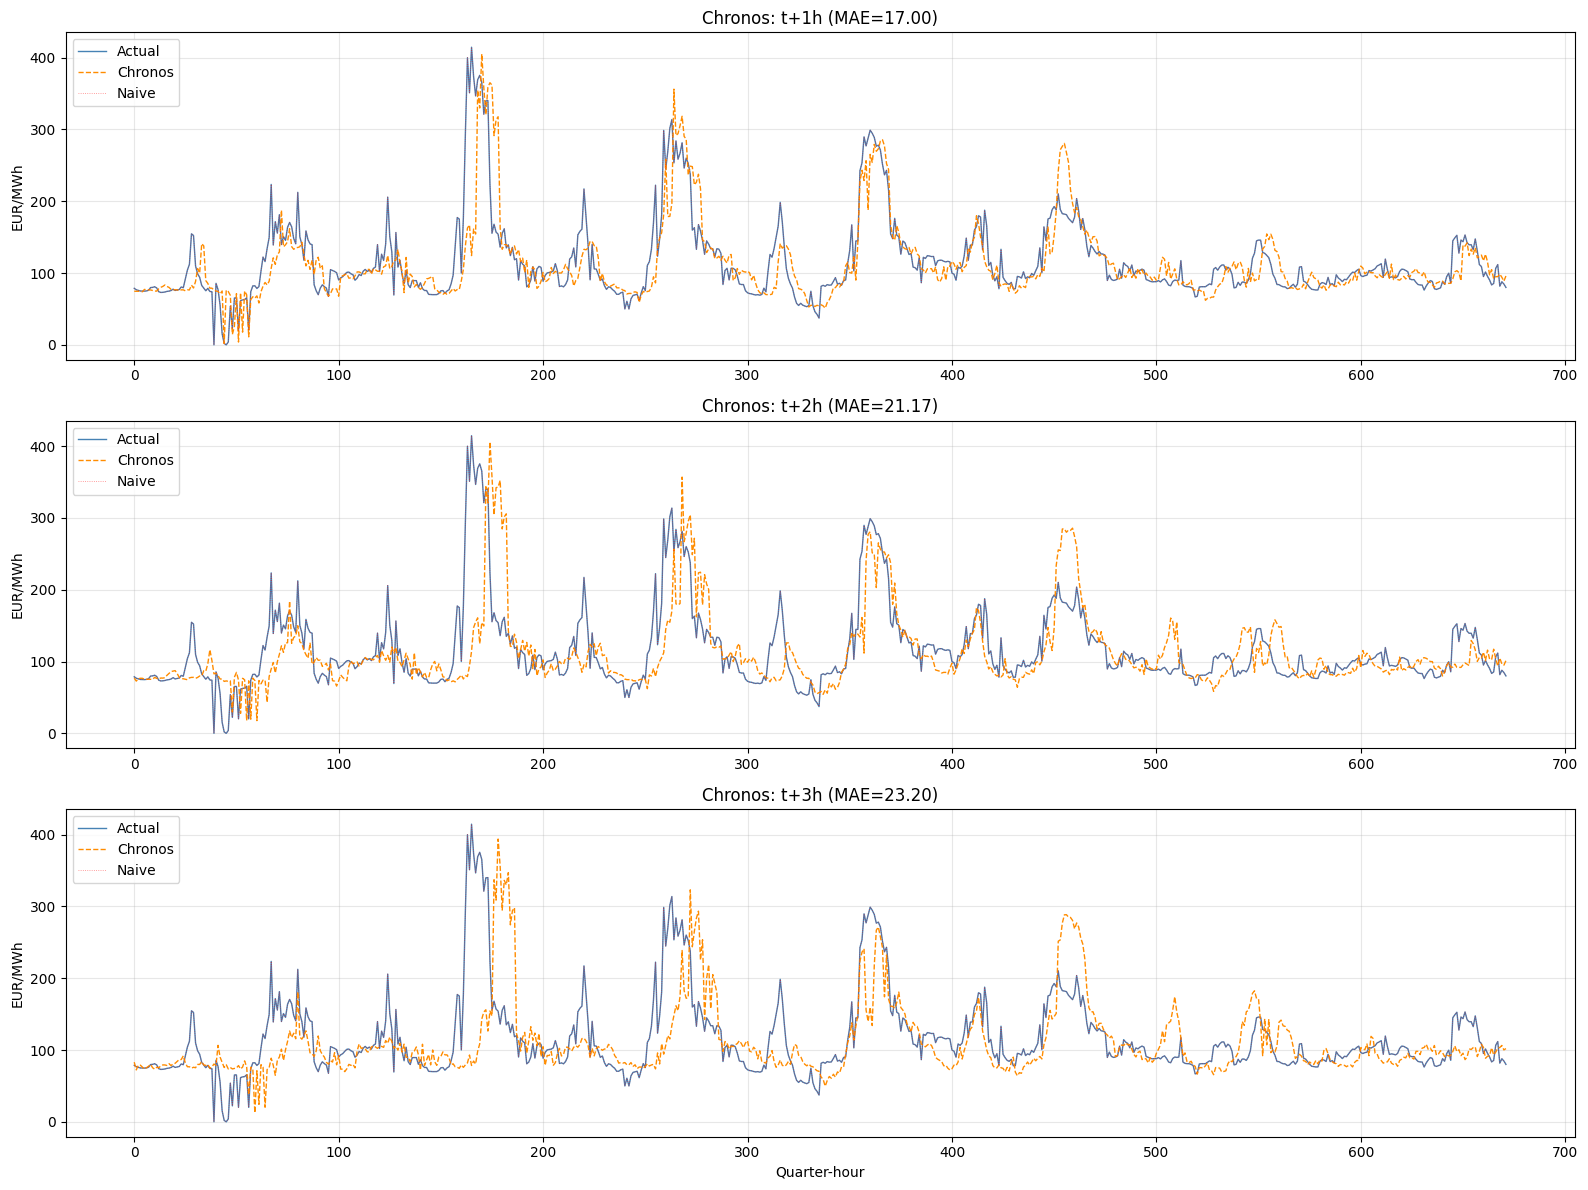

In [8]:
# 7-day prediction plot
N_PLOT = min(96 * 7, len(preds_chronos['1h']))

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
for h_idx, h in enumerate(horizon_names):
    ax = axes[h_idx]
    y_true = np.array(actuals_chronos[h])
    y_pred = np.array(preds_chronos[h])

    ax.plot(y_true[-N_PLOT:], color='steelblue', linewidth=1, label='Actual')
    ax.plot(y_pred[-N_PLOT:], color='darkorange', linewidth=1, linestyle='--', label='Chronos')

    # Naive
    naive_plot = []
    for idx in evaluated_indices[-N_PLOT:]:
        naive_plot.append(ida_series[idx])
    ax.plot(naive_plot[-N_PLOT:], color='red', linewidth=0.6, linestyle=':', alpha=0.5, label='Naive')

    ax.set_ylabel('EUR/MWh')
    ax.set_title(f'Chronos: t+{h} (MAE={mean_absolute_error(y_true, y_pred):.2f})')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Quarter-hour')
plt.tight_layout(); plt.show()

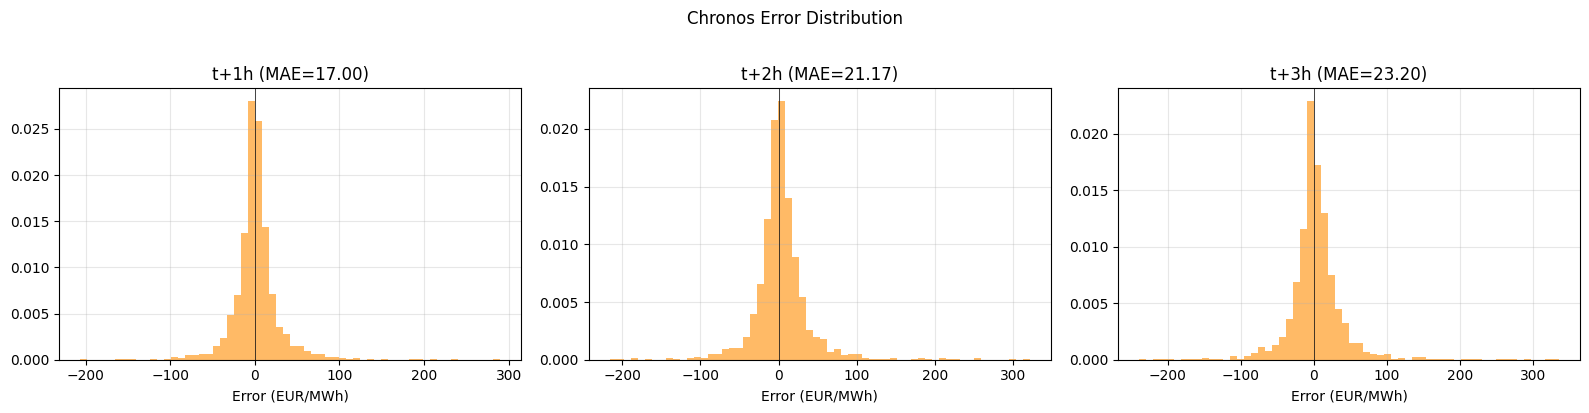

In [9]:
# Error distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for h_idx, h in enumerate(horizon_names):
    ax = axes[h_idx]
    y_true = np.array(actuals_chronos[h])
    y_pred = np.array(preds_chronos[h])
    err = y_true - y_pred
    ax.hist(err, bins=60, alpha=0.6, color='darkorange', density=True)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(f't+{h} (MAE={mean_absolute_error(y_true, y_pred):.2f})')
    ax.set_xlabel('Error (EUR/MWh)'); ax.grid(True, alpha=0.3)
plt.suptitle('Chronos Error Distribution', y=1.02)
plt.tight_layout(); plt.show()

## 6. Summary

**Chronos** is a pre-trained time series transformer from Amazon (chronos-t5-small, 46M parameters). It performs zero-shot forecasting using only the raw IDA price history — no engineered features, no domain knowledge, no training on our data.

**Key comparison:**
- **Chronos** sees only raw price series (univariate) → pure time series pattern matching
- **TabPFN** sees engineered features at current timestep → tabular pattern matching
- **Our models** see engineered features across multiple timesteps → temporal + domain knowledge

**Hierarchy (expected):**
1. Our trained models (XGBoost, MLP, LSTM) — best, because they combine domain features + temporal modeling
2. Chronos — middle, because it captures temporal dynamics but lacks domain features (ISP revisions, BM price)
3. TabPFN — varies, because it sees features but not temporal structure
4. Naive / Linear — worst

This confirms that domain-specific feature engineering (ISP forecast revisions, BM rolling statistics) provides value beyond what general-purpose foundation models can capture.